In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def moving_average(x, n: int = 100):
    ret = np.cumsum(x, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1 :] / n

In [3]:
ground_truth = {
    "sasrec_0" : 0.6449585714285714,
    "sasrec_1" : 0.5152890476190476,
    "sasrec_2" : 0.1710030476190476,
}

discounted_ground_truth = {
    "sasrec_0" : 0.3524044871067294,
    "sasrec_1" : 0.3009161713956903,
    "sasrec_2" : 0.1042907585867385,
}

In [4]:
EXPERIMENTS_FOLDER = 'experiments'
MODEL_NAME = 'sasrec_2'
SEEDS = [784, 12345, 89290]


data = pd.DataFrame()
for seed in SEEDS:
    dir = f'{EXPERIMENTS_FOLDER}/sim_{MODEL_NAME}_50k_seed_{seed}'
    values = np.load(f'{dir}/values.npy')
    values = moving_average(values, n=10)
    data_new = pd.DataFrame({
        'value' : values,
        'step' : np.arange(len(values))
    })
    data_new['policy'] = MODEL_NAME
    data = pd.concat([data, data_new], ignore_index=True, axis=0)

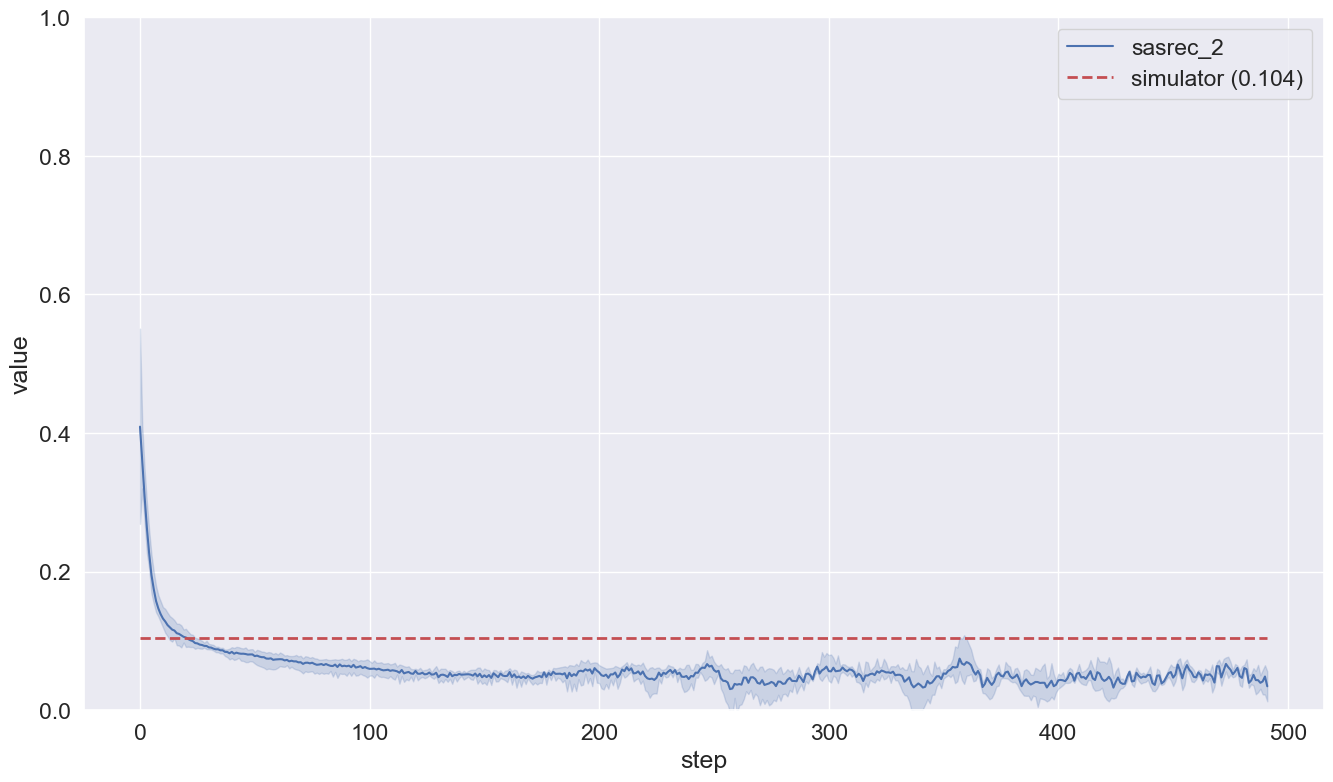

In [5]:
sns.set_theme(rc={'figure.figsize':(16, 9)}, font_scale=1.5)

sns.lineplot(data=data, x='step', y='value', hue='policy', errorbar='ci')
plt.hlines(
    y=discounted_ground_truth[MODEL_NAME],
    xmin=0, xmax=data['step'].max(),
    linestyles='--',
    linewidth=2,
    colors='r',
    label=f'simulator ({round(discounted_ground_truth[MODEL_NAME], 3)})'
)
plt.ylim(0, 1)
# plt.savefig("./images/dice_sim.pdf", bbox_inches='tight')
plt.legend()
plt.show()